# Automatic Text Summarization — BBC News Dataset
**Dataset:** BBC News (2225 articles, 5 categories)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import networkx as nx

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from rouge_score import rouge_scorer
from wordcloud import WordCloud

## 2. Load Dataset and Basic Dataset Information

In [2]:
df = pd.read_csv('bbc-text.csv') 

In [3]:
print('Dataset Shape:')
print(df.shape)

Dataset Shape:
(2225, 2)


In [4]:
print('Dataset Info:')
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None


In [5]:
print("NULL VALUES")
print(df.isnull().sum())

NULL VALUES
category    0
text        0
dtype: int64


In [6]:
print('Categories:')
print(df['category'].unique())
print('\nCategory Counts:')
print(df['category'].value_counts())

Categories:
['tech' 'business' 'sport' 'entertainment' 'politics']

Category Counts:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [7]:
print('Sample Article:')
print(df['text'][0][:1000])

Sample Article:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being b

## 3. Exploratory Data Analysis (EDA)
### 3.1 Word count per article

In [8]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print('Word count stats:')
print(df['word_count'].describe().round(1))

Word count stats:
count    2225.0
mean      390.3
std       241.8
min        90.0
25%       250.0
50%       337.0
75%       479.0
max      4492.0
Name: word_count, dtype: float64


In [9]:
df['sent_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))
print('Sentence count stats:')
print(df['sent_count'].describe().round(1))

Sentence count stats:
count    2225.0
mean       17.8
std        11.7
min         4.0
25%        11.0
50%        15.0
75%        22.0
max       227.0
Name: sent_count, dtype: float64


### 3.2 Category Distribution

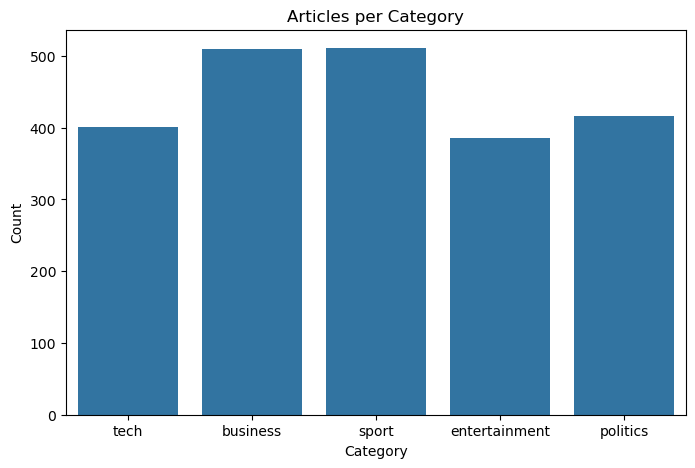

In [10]:
plt.figure(figsize=(8,5),)
sns.countplot(x='category', data=df)
plt.title('Articles per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

### 3.3 Word Count Distribution

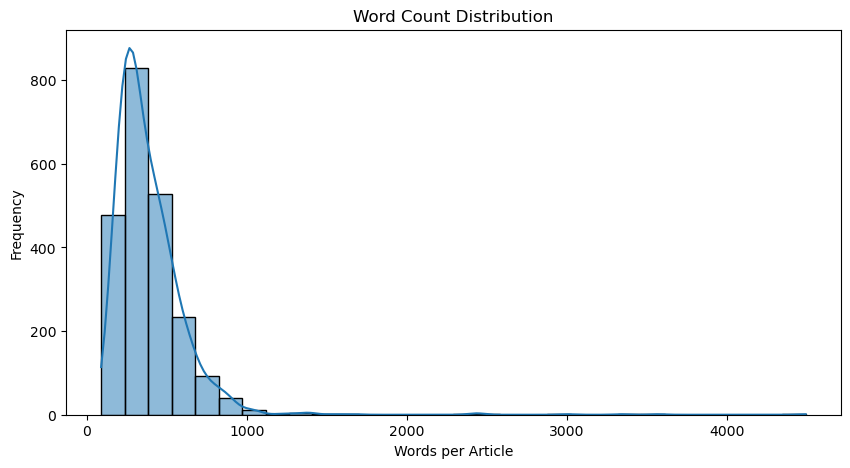

In [11]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Words per Article')
plt.ylabel('Frequency')
plt.show()

### 3.4 Average Word Count Per Category

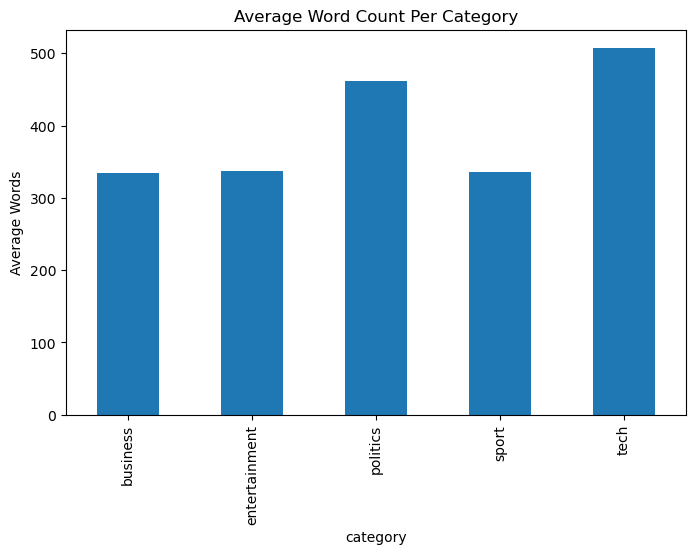

In [12]:
avg_words = df.groupby('category')['word_count'].mean()
plt.figure(figsize=(8,5))
avg_words.plot(kind='bar')
plt.title('Average Word Count Per Category')
plt.ylabel('Average Words')
plt.show()

## 4. Text Preprocessing
Cleaning → Tokenization → Stopword Removal → Lemmatization → POS Tagging
### 4.1 Create Stopwords and Lemmatizer

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 4.2 Cleaning Function

In [14]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

### 4.3 Apply Cleaning

In [15]:
df['clean_text'] = df['text'].apply(clean_text)

print(df[['category', 'clean_text']].head())

        category                                         clean_text
0           tech  tv future hand viewer home theatre system plas...
1       business  worldcom bos left book alone former worldcom b...
2          sport  tiger wary farrell gamble leicester say rushed...
3          sport  yeading face newcastle fa cup premiership side...
4  entertainment  ocean twelve raid box office ocean twelve crim...


### 4.4 Tokenization Example

In [16]:
sample_text = df['text'][0]
sentences = sent_tokenize(sample_text)
words = word_tokenize(sample_text)
print('First 5 Sentences:')
print(sentences[:5])
print('\nFirst 20 Words:')
print(words[:20])

First 5 Sentences:
['tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.', 'that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes.', 'with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.', 'one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr).', 'these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.']

First 20 Words:
['tv', 'future', 'in', 'the', 'hands', 'of', 'viewers'

### 4.5 POS Tagging

In [17]:
sample_words = word_tokenize(clean_text(sample_text))
pos_tags = pos_tag(sample_words[:20])
print('POS Tags (first 20):')
print(f'{"Word":<15} {"POS Tag"}')
print('-'*25)
for word, tag in pos_tags:
    print(f'{word:<15} {tag}')

POS Tags (first 20):
Word            POS Tag
-------------------------
tv              NN
future          NN
hand            NN
viewer          FW
home            NN
theatre         NN
system          NN
plasma          JJ
highdefinition  NN
tv              NN
digital         JJ
video           NN
recorder        NN
moving          VBG
living          JJ
room            NN
way             NN
people          NNS
watch           VBP
tv              NN


## 5. TF-IDF Based Summarization
### 5.1 TF-IDF Summary Function

In [18]:
def tfidf_summarizer(text, num_sentences=3):
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        dummy_scores = np.ones(len(sentences))
        return text, dummy_scores
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    ranked_sentences = np.argsort(sentence_scores)[::-1]
    selected_sentences = sorted(ranked_sentences[:num_sentences])
    summary = ' '.join([sentences[i] for i in selected_sentences])
    return summary, sentence_scores

### 5.2 Generate TF-IDF Summary

In [19]:
article = df['text'][0]
summary_tfidf, tfidf_scores = tfidf_summarizer(article)
print('Original Article:')
print(article[:2000])
print('\nTF-IDF Summary:')
print(summary_tfidf)

Original Article:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being

### 5.3 TF-IDF Sentence Score Chart

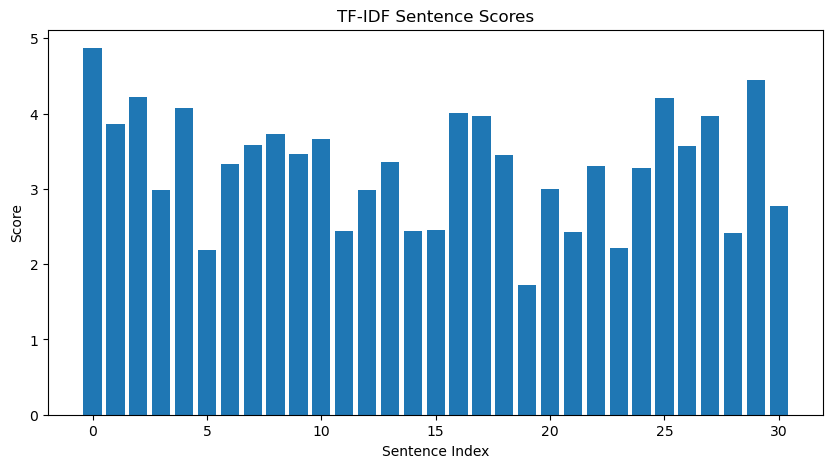

In [20]:
plt.figure(figsize=(10,5))
plt.bar(range(len(tfidf_scores)), tfidf_scores)
plt.title('TF-IDF Sentence Scores')
plt.xlabel('Sentence Index')
plt.ylabel('Score')
plt.show()

## 6. TextRank Summarization
### 6.1 TextRank Function

In [21]:
def textrank_summarizer(text, num_sentences=3):
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        dummy_scores = {i: 1.0 for i in range(len(sentences))}
        dummy_matrix = np.ones((len(sentences), len(sentences)))
        
        return text, dummy_scores, dummy_matrix
    vectorizer = TfidfVectorizer(stop_words='english')
    sentence_vectors = vectorizer.fit_transform(sentences)
    similarity_matrix = cosine_similarity(sentence_vectors)
    graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(graph)
    ranked_sentences = sorted(((scores[i], s, i) for i, s in enumerate(sentences)), reverse=True)
    selected = sorted(ranked_sentences[:num_sentences], key=lambda x: x[2])
    summary = ' '.join([sentence for score, sentence, idx in selected])
    return summary, scores, similarity_matrix

### 6.2 Generate TextRank Summary

In [22]:
summary_textrank, textrank_scores, sim_matrix = textrank_summarizer(article)
print('TextRank Summary:\n')
print(summary_textrank)

TextRank Summary:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time. these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want. what this means  said stacey jolna  senior vice president of tv guide tv group  is that the way people find the content they want to watch has to be simplified for tv viewers.


### 6.3 TextRank Score Visualization

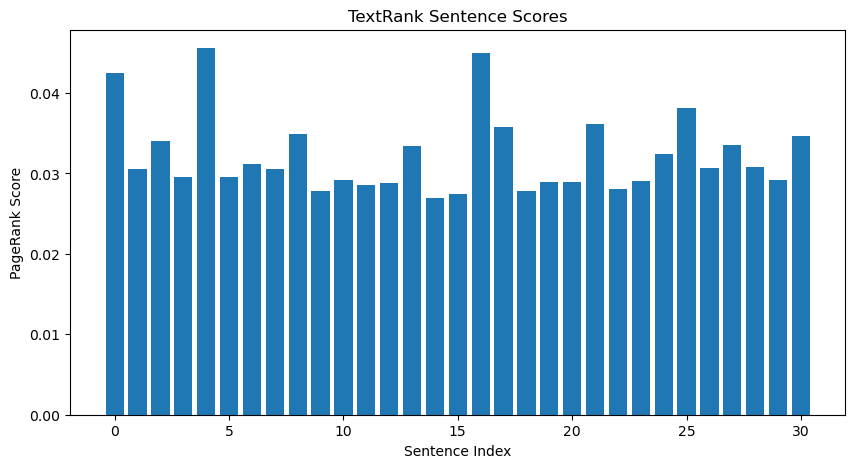

In [23]:
plt.figure(figsize=(10,5))
plt.bar(textrank_scores.keys(), textrank_scores.values())
plt.title('TextRank Sentence Scores')
plt.xlabel('Sentence Index')
plt.ylabel('PageRank Score')
plt.show()

### 6.4 Similarity Matrix Visualization

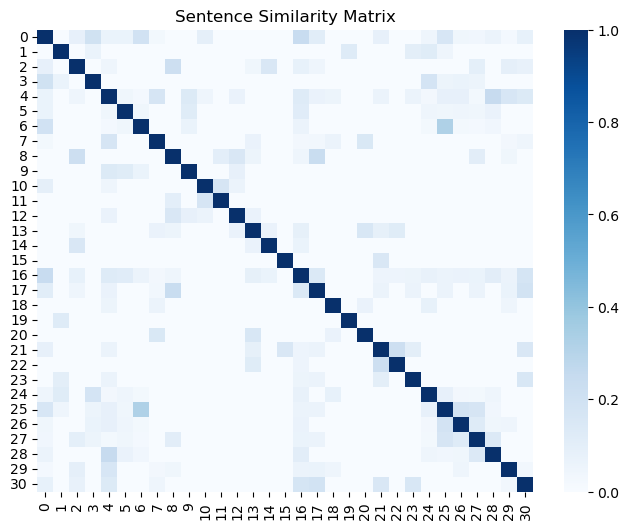

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, cmap='Blues')
plt.title('Sentence Similarity Matrix')
plt.show()

## 7. Summary Length Comparison

In [25]:
comparison_df = pd.DataFrame({
    'Method': ['TF-IDF', 'TextRank'],
    'Summary': [summary_tfidf, summary_textrank]
})

print(comparison_df)

     Method                                            Summary
0    TF-IDF  tv future in the hands of viewers with home th...
1  TextRank  tv future in the hands of viewers with home th...


### 7.1 Summary Length Comparison

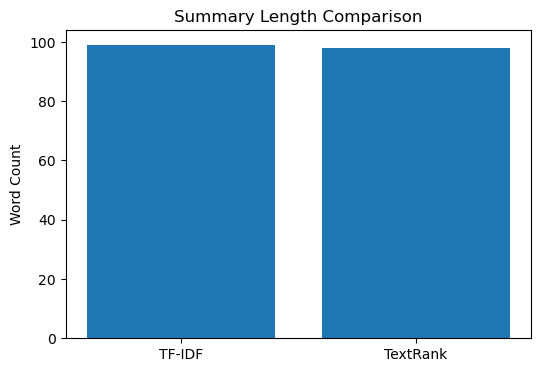

In [26]:
summary_lengths = [
    len(summary_tfidf.split()),
    len(summary_textrank.split())
]

methods = ['TF-IDF', 'TextRank']

plt.figure(figsize=(6,4))
plt.bar(methods, summary_lengths)
plt.title('Summary Length Comparison')
plt.ylabel('Word Count')
plt.show()

### Run Summarization on Multiple Articles

In [27]:
for category in df['category'].unique():
    print('\n' + '='*50)
    print('CATEGORY:', category)
    print('='*50)
    sample_article = df[df['category'] == category]['text'].iloc[0]
    tfidf_summary, _ = tfidf_summarizer(sample_article)
    textrank_summary, _, _ = textrank_summarizer(sample_article)
    print('\nTF-IDF SUMMARY:\n')
    print(tfidf_summary)

    print('\nTEXTRANK SUMMARY:\n')
    print(textrank_summary)


CATEGORY: tech

TF-IDF SUMMARY:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices. and microsoft chief bill gates announced in his pre-show keynote speech a partnership with tivo  called tivotogo  which means people can play recorded programmes on windows pcs and mobile devices.

TEXTRANK SUMMARY:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time. these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record

## 8. ROUGE Evaluation
### 8.1 ROUGE Function

In [28]:
def rouge_scores(reference, generated):

    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    scores = scorer.score(reference, generated)

    return {
        'ROUGE-1': scores['rouge1'].fmeasure,
        'ROUGE-2': scores['rouge2'].fmeasure,
        'ROUGE-L': scores['rougeL'].fmeasure
    }

### 8.2 Evaluate Summaries

In [29]:
reference = ' '.join(sent_tokenize(article)[:3])
rouge_tfidf = rouge_scores(reference, summary_tfidf)
rouge_textrank = rouge_scores(reference, summary_textrank)

print('TF-IDF ROUGE Scores:\n')
print(rouge_tfidf)

print('\nTextRank ROUGE Scores:\n')
print(rouge_textrank)

TF-IDF ROUGE Scores:

{'ROUGE-1': 0.7227722772277227, 'ROUGE-2': 0.68, 'ROUGE-L': 0.693069306930693}

TextRank ROUGE Scores:

{'ROUGE-1': 0.5373134328358209, 'ROUGE-2': 0.371859296482412, 'ROUGE-L': 0.44776119402985076}


### 8.3 ROUGE Score Comparison Chart

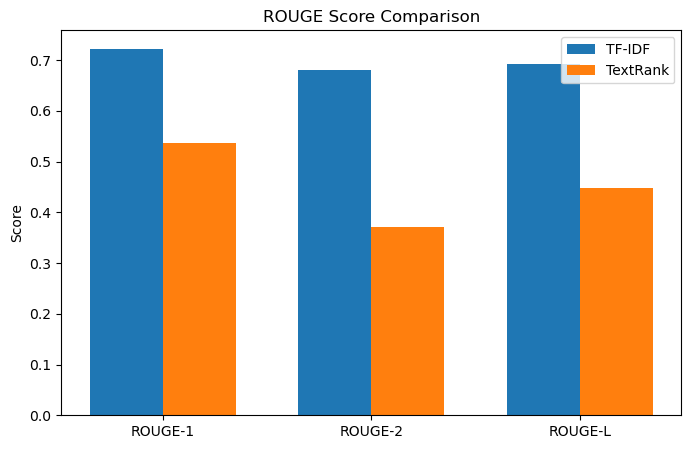

In [30]:
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

values_tfidf = [rouge_tfidf[m] for m in metrics]
values_textrank = [rouge_textrank[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, values_tfidf, width, label='TF-IDF')
plt.bar(x + width/2, values_textrank, width, label='TextRank')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('ROUGE Score Comparison')
plt.legend()
plt.show()

### 8.4 Average ROUGE Scores Across Multiple Articles

In [36]:
tfidf_r1 = []
tfidf_r2 = []
tfidf_rl = []

textrank_r1 = []
textrank_r2 = []
textrank_rl = []

for i in range(20):

    article = df['text'][i]

    reference = article[:1000]

    tfidf_summary, _ = tfidf_summarizer(article)
    textrank_summary, _, _ = textrank_summarizer(article)

    score_tfidf = rouge_scores(reference, tfidf_summary)
    score_textrank = rouge_scores(reference, textrank_summary)

    tfidf_r1.append(score_tfidf['ROUGE-1'])
    tfidf_r2.append(score_tfidf['ROUGE-2'])
    tfidf_rl.append(score_tfidf['ROUGE-L'])

    textrank_r1.append(score_textrank['ROUGE-1'])
    textrank_r2.append(score_textrank['ROUGE-2'])
    textrank_rl.append(score_textrank['ROUGE-L'])

print('Average TF-IDF ROUGE-1:', np.mean(tfidf_r1))
print('Average TextRank ROUGE-1:', np.mean(textrank_r1))
print('Average TF-IDF ROUGE-2:', np.mean(tfidf_r2))
print('Average TextRank ROUGE-2:', np.mean(textrank_r2))
print('Average TF-IDF ROUGE-L:', np.mean(tfidf_rl))
print('Average TextRank ROUGE-L:', np.mean(textrank_rl))

Average TF-IDF ROUGE-1: 0.505243961664217
Average TextRank ROUGE-1: 0.5164968830817869
Average TF-IDF ROUGE-2: 0.39870798203820257
Average TextRank ROUGE-2: 0.4614572048248453
Average TF-IDF ROUGE-L: 0.42225160675241125
Average TextRank ROUGE-L: 0.47899297129989443


### 8.5 ROUGE Average Visualization

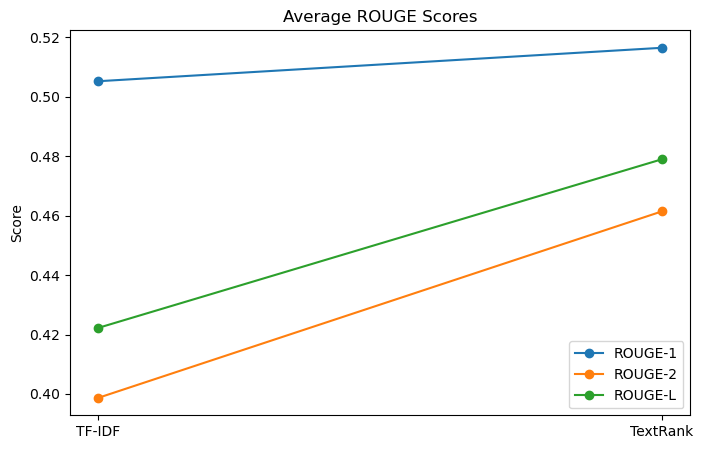

In [37]:
methods = ['TF-IDF', 'TextRank']

rouge1_avg = [np.mean(tfidf_r1), np.mean(textrank_r1)]
rouge2_avg = [np.mean(tfidf_r2), np.mean(textrank_r2)]
rougel_avg = [np.mean(tfidf_rl), np.mean(textrank_rl)]

plt.figure(figsize=(8,5))
plt.plot(methods, rouge1_avg, marker='o', label='ROUGE-1')
plt.plot(methods, rouge2_avg, marker='o', label='ROUGE-2')
plt.plot(methods, rougel_avg, marker='o', label='ROUGE-L')

plt.title('Average ROUGE Scores')
plt.ylabel('Score')
plt.legend()
plt.show()

## 9. Summarize Any Article By Index

In [38]:
def summarize_article(index):

    article = df['text'][index]

    print('\nCATEGORY:', df['category'][index])

    print('\nORIGINAL ARTICLE:\n')
    print(article[:2000])

    tfidf_summary, _ = tfidf_summarizer(article)

    textrank_summary, _, _ = textrank_summarizer(article)

    print('\nTF-IDF SUMMARY:\n')
    print(tfidf_summary)

    print('\nTEXTRANK SUMMARY:\n')
    print(textrank_summary)

In [39]:
summarize_article(10)


CATEGORY: entertainment

ORIGINAL ARTICLE:

berlin cheers for anti-nazi film a german movie about an anti-nazi resistance heroine has drawn loud applause at berlin film festival.  sophie scholl - the final days portrays the final days of the member of the white rose movement. scholl  21  was arrested and beheaded with her brother  hans  in 1943 for distributing leaflets condemning the  abhorrent tyranny  of adolf hitler. director marc rothemund said:  i have a feeling of responsibility to keep the legacy of the scholls going.   we must somehow keep their ideas alive   he added.  the film drew on transcripts of gestapo interrogations and scholl s trial preserved in the archive of communist east germany s secret police. their discovery was the inspiration behind the film for rothemund  who worked closely with surviving relatives  including one of scholl s sisters  to ensure historical accuracy on the film. scholl and other members of the white rose resistance group first started distrib

## 10. Word Clouds Per Category

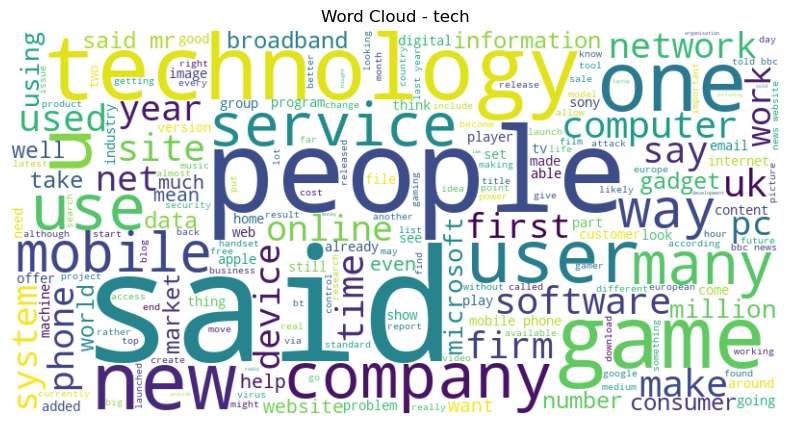

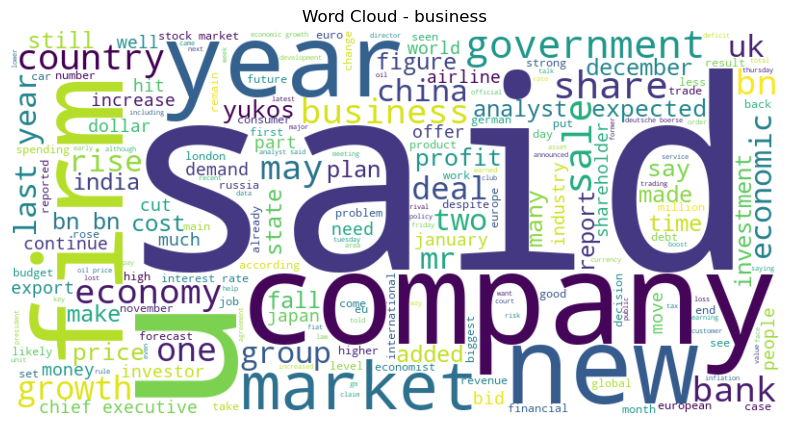

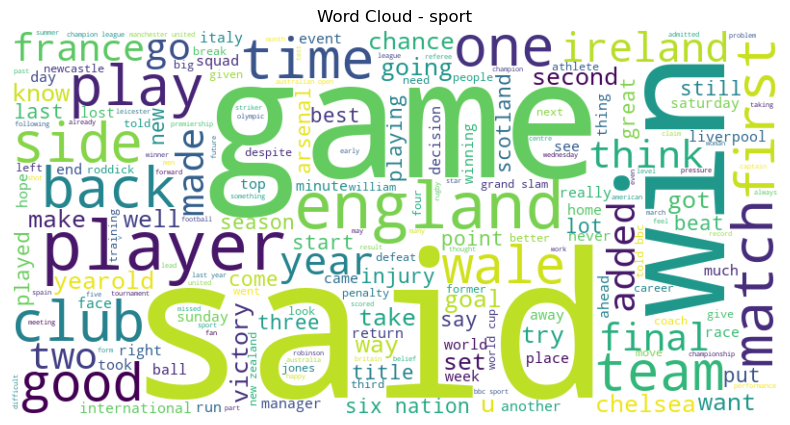

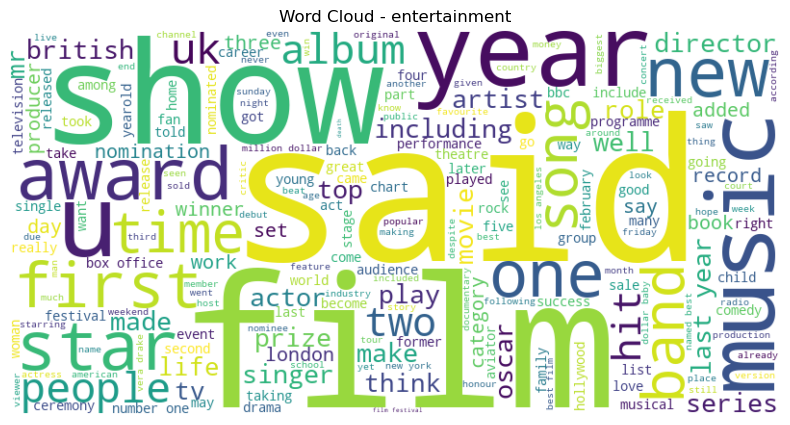

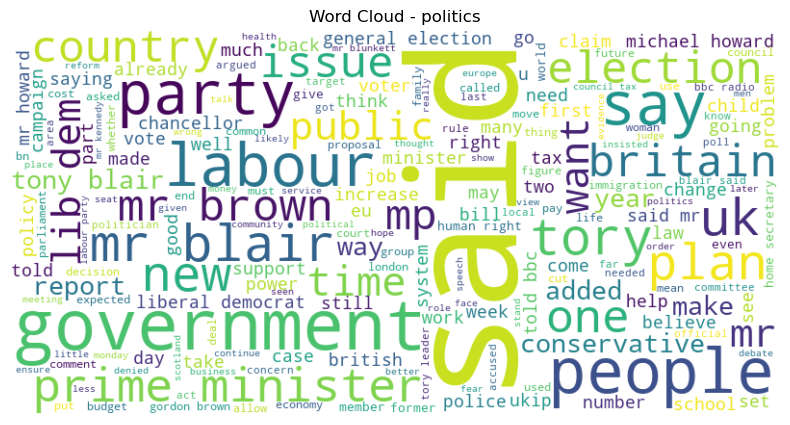

In [40]:
categories = df['category'].unique()

for category in categories:

    text = ' '.join(df[df['category'] == category]['clean_text'])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {category}')
    plt.show()